# 📊 ANALYSE EXPLORATOIRE DES DONNÉES (EDA)

## 0️⃣ Imports & Configuration

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
import sqlite3
import warnings
import os

In [50]:
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────
plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['font.family']     = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

COLORS = {
    'red':    '#E74C3C',
    'blue':   '#2E86C1',
    'green':  '#27AE60',
    'orange': '#F39C12',
    'purple': '#8E44AD',
    'gray':   '#95A5A6',
}

DATA_DIR = 'data'
OUTPUT_DIR = 'outputs/eda'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f' Dossier data : {os.listdir(DATA_DIR)}')

 Dossier data : ['dpe', 'geo', 'logements', 'population', 'processed', 'revenus']


---
## 1️⃣ Chargement & Aperçu des Datasets

In [51]:
# ── Chargement DPE (3 régions) ────────────────────────
dpe_idf = pd.read_csv(f'{DATA_DIR}/dpe/dpe_11.csv', dtype={'code_insee_commune_actualise': str}, low_memory=False)
dpe_hdf = pd.read_csv(f'{DATA_DIR}/dpe/dpe_32.csv', dtype={'code_insee_commune_actualise': str}, low_memory=False)
dpe_bre = pd.read_csv(f'{DATA_DIR}/dpe/dpe_53.csv', dtype={'code_insee_commune_actualise': str}, low_memory=False)

# Fusion DPE + étiquette région
dpe_idf['region'] = 'Île-de-France'
dpe_hdf['region'] = 'Hauts-de-France'
dpe_bre['region'] = 'Bretagne'
dpe = pd.concat([dpe_idf, dpe_hdf, dpe_bre], ignore_index=True)

# Normaliser colonne code INSEE
if 'code_insee_commune_actualise' in dpe.columns:
    dpe = dpe.rename(columns={'code_insee_commune_actualise': 'CODGEO'})

# ── Chargement Population ─────────────────────────────
pop = pd.read_csv(f'{DATA_DIR}/population/population_communes.csv', dtype={'CODGEO': str}, low_memory=False)

# ── Chargement Revenus ───────────────────────────────
rev = pd.read_csv(f'{DATA_DIR}/revenus/revenus_communes.csv', dtype={'CODGEO': str}, low_memory=False)

# ── Chargement Logements depuis SQLite ───────────────
conn = sqlite3.connect(f'{DATA_DIR}/logements/logements_rp2022.db')
log = pd.read_sql('SELECT * FROM logements_communes', conn)
log['CODGEO'] = log['CODGEO'].astype(str)
conn.close()

# ── Chargement GeoJSON ───────────────────────────────
geo = gpd.read_file(f'{DATA_DIR}/geo/communes_3regions.geojson')

print(' Tous les datasets chargés')
print(f'   DPE total    : {len(dpe):,} lignes')
print(f'   Population   : {len(pop):,} communes')
print(f'   Revenus      : {len(rev):,} communes')
print(f'   Logements    : {len(log):,} communes')
print(f'   GeoJSON      : {len(geo):,} communes')

 Tous les datasets chargés
   DPE total    : 15,000 lignes
   Population   : 6,250 communes
   Revenus      : 6,250 communes
   Logements    : 1,683 communes
   GeoJSON      : 6,250 communes


In [52]:
# ── Aperçu de chaque dataset ──────────────────────────
datasets = {'DPE': dpe, 'Population': pop, 'Revenus': rev, 'Logements': log}

for nom, df in datasets.items():
    print(f'\n{'='*50}')
    print(f' {nom} — {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
    print(f'   Colonnes : {list(df.columns)}')
    display(df.head(5))


 DPE — 15,000 lignes × 11 colonnes
   Colonnes : ['CODGEO', 'etiquette_dpe', 'etiquette_ges', 'type_batiment', 'annee_construction', 'surface_habitable_logement', 'consommation_energie_primaire', 'date_reception_dpe', 'region_code', 'source', 'region']


,CODGEO,etiquette_dpe,etiquette_ges,type_batiment,annee_construction,surface_habitable_logement,consommation_energie_primaire,date_reception_dpe,region_code,source,region
0,77131,F,D,appartement,1953,60.2,337.0,2021-07-01,11,simule_distributions_ademe_2023,Île-de-France
1,77140,E,G,maison,1982,31.6,360.0,2021-07-01,11,simule_distributions_ademe_2023,Île-de-France
2,91015,E,G,appartement,1982,48.9,648.0,2021-07-01,11,simule_distributions_ademe_2023,Île-de-France
3,78346,C,G,appartement,1997,54.9,298.0,2021-07-01,11,simule_distributions_ademe_2023,Île-de-France
4,93186,B,E,maison,1990,45.0,131.0,2021-07-02,11,simule_distributions_ademe_2023,Île-de-France



 Population — 6,250 lignes × 5 colonnes
   Colonnes : ['CODGEO', 'NOM_COMMUNE', 'POPULATION', 'DEP', 'REG']


,CODGEO,NOM_COMMUNE,POPULATION,DEP,REG
0,75056,Paris,2103778,75,11
1,77001,Achères-la-Forêt,1191,77,11
2,77002,Amillis,830,77,11
3,77003,Amponville,349,77,11
4,77004,Andrezel,336,77,11



 Revenus — 6,250 lignes × 9 colonnes
   Colonnes : ['CODGEO', 'NOM_COMMUNE', 'POPULATION', 'DEP', 'REG', 'MED21', 'TP6021', 'MEN_PAUV', 'SOURCE_REVENUS']


,CODGEO,NOM_COMMUNE,POPULATION,DEP,REG,MED21,TP6021,MEN_PAUV,SOURCE_REVENUS
0,75056,Paris,2103778,75,11,31157.0,10.0,11.6,insee_stats_dep_2022
1,77001,Achères-la-Forêt,1191,77,11,23651.0,20.5,22.6,insee_stats_dep_2022
2,77002,Amillis,830,77,11,20396.0,25.4,25.8,insee_stats_dep_2022
3,77003,Amponville,349,77,11,23841.0,15.8,15.2,insee_stats_dep_2022
4,77004,Andrezel,336,77,11,25784.0,17.5,18.1,insee_stats_dep_2022



 Logements — 1,683 lignes × 7 colonnes
   Colonnes : ['CODGEO', 'NB_LOGEMENTS', 'NB_RP', 'NB_LOGVAC', 'NB_MAISON', 'NB_APPART', 'DEP']


,CODGEO,NB_LOGEMENTS,NB_RP,NB_LOGVAC,NB_MAISON,NB_APPART,DEP
0,75001,885,721,47,449,379,75
1,75002,24000,17028,1312,11855,5154,75
2,75003,3404,2469,338,1658,1131,75
3,75004,3783,3195,387,1078,1997,75
4,75005,1645,1165,216,735,452,75


---
## 2️⃣ Statistiques Descriptives

In [53]:
print(' STATISTIQUES DESCRIPTIVES — DPE')
print('='*60)
display(dpe.describe(include='all').T)


 STATISTIQUES DESCRIPTIVES — DPE


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CODGEO,15000,5738,29321,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
etiquette_dpe,15000,7,D,3778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
etiquette_ges,15000,7,E,3707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_batiment,15000,3,maison,7476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annee_construction,15000.0,NaN,NaN,NaN,1975.773933,23.241378,1920.0,1965.0,1978.0,1991.0,2019.0
surface_habitable_logement,15000.0,NaN,NaN,NaN,76.046253,40.296109,18.0,47.9,67.5,93.9,400.0
consommation_energie_primaire,15000.0,NaN,NaN,NaN,368.930933,176.521516,50.0,223.0,339.0,521.0,700.0
date_reception_dpe,15000,1280,2024-12-15,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_code,15000.0,NaN,NaN,NaN,32.0,17.147,11.0,11.0,32.0,53.0,53.0
source,15000,1,simule_distributions_ademe_2023,15000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
print(' STATISTIQUES DESCRIPTIVES — REVENUS')
cols_num_rev = rev.select_dtypes(include='number').columns.tolist()
if cols_num_rev:
    display(rev[cols_num_rev].describe().T.round(2))
else:
    # Colonnes en string → convertir
    for col in ['MED21', 'TP6021', 'MEN_PAUV', 'POPULATION']:
        if col in rev.columns:
            rev[col] = pd.to_numeric(rev[col], errors='coerce')
    display(rev.select_dtypes(include='number').describe().T.round(2))

 STATISTIQUES DESCRIPTIVES — REVENUS


,count,mean,std,min,25%,50%,75%,max
POPULATION,6250.0,3504.74,28373.14,7.0,284.00,679.0,1928.75,2103778.0
DEP,6250.0,55.06,27.10,2.0,35.00,60.0,77.00,95.0
REG,6250.0,31.78,13.20,11.0,32.00,32.0,32.00,53.0
MED21,6250.0,20277.29,4112.21,11520.0,17465.75,19903.0,22626.50,40577.0
TP6021,6250.0,23.39,5.51,3.0,20.10,23.8,27.20,38.9
MEN_PAUV,6250.0,23.35,6.20,2.4,19.40,23.4,27.40,45.1


In [55]:
print(' STATISTIQUES DESCRIPTIVES — LOGEMENTS')
for col in log.select_dtypes(include='object').columns:
    if col != 'CODGEO':
        log[col] = pd.to_numeric(log[col], errors='coerce')
display(log.select_dtypes(include='number').describe().T.round(0))

 STATISTIQUES DESCRIPTIVES — LOGEMENTS


,count,mean,std,min,25%,50%,75%,max
NB_LOGEMENTS,1683.0,4182.0,11233.0,1.0,419.0,1141.0,3310.0,167597.0
NB_RP,1683.0,3109.0,8245.0,0.0,312.0,851.0,2472.0,131513.0
NB_LOGVAC,1683.0,409.0,1044.0,0.0,39.0,111.0,314.0,13490.0
NB_MAISON,1683.0,1516.0,3970.0,0.0,146.0,421.0,1225.0,59345.0
NB_APPART,1683.0,1573.0,4214.0,0.0,150.0,430.0,1202.0,59055.0
DEP,1683.0,65.0,27.0,2.0,56.0,75.0,91.0,95.0


---
## 3️⃣ Valeurs Manquantes & Doublons

In [56]:
# pour calcule le nombres des duplications dans chaque dataset
print(' NOMBRE DE DUPLICATIONS PAR DATASET')
for nom, df in datasets.items():
    dupli_count = df.duplicated().sum()
    print(f'   {nom} : {dupli_count:,} duplications')

##pour calcule le nombres des valeurs manquantes dans chaque dataset
print('\n NOMBRE DE VALEURS MANQUANTES PAR DATASET')
for nom, df in datasets.items():
    missing_count = df.isnull().sum().sum()
    print(f'   {nom} : {missing_count:,} valeurs manquantes')


 NOMBRE DE DUPLICATIONS PAR DATASET
   DPE : 0 duplications
   Population : 0 duplications
   Revenus : 0 duplications
   Logements : 0 duplications

 NOMBRE DE VALEURS MANQUANTES PAR DATASET
   DPE : 0 valeurs manquantes
   Population : 0 valeurs manquantes
   Revenus : 0 valeurs manquantes
   Logements : 0 valeurs manquantes


In [57]:
# Fonction d'analyse de qualité des données
def analyse_qualite(df, nom):
    total = len(df)
    print(f'\n🔍 {nom} — Qualité des données')
    print(f'   Lignes totales : {total:,}')
    
    # Valeurs manquantes
    missing = df.isnull().sum()
    missing_pct = (missing / total * 100).round(2)
    missing_df = pd.DataFrame({
        'Valeurs manquantes': missing,
        '% manquant': missing_pct
    }).query('`Valeurs manquantes` > 0').sort_values('% manquant', ascending=False)
    
    if len(missing_df) > 0:
        print(f'   ⚠️  Colonnes avec valeurs manquantes :')
        display(missing_df)
    else:
        print('   ✅ Aucune valeur manquante')
    
    # Doublons
    dupl = df.duplicated().sum()
    print(f'   Doublons exacts : {dupl:,} ({dupl/total*100:.2f}%)')
    
    # Doublons sur code INSEE
    if 'CODGEO' in df.columns:
        dupl_geo = df['CODGEO'].duplicated().sum()
        print(f'   Doublons CODGEO : {dupl_geo:,}')
    
    return missing_df

for nom, df in datasets.items():
    analyse_qualite(df, nom)
analyse_qualite(dpe, 'DPE (complet)')


🔍 DPE — Qualité des données
   Lignes totales : 15,000
   ✅ Aucune valeur manquante
   Doublons exacts : 0 (0.00%)
   Doublons CODGEO : 9,262

🔍 Population — Qualité des données
   Lignes totales : 6,250
   ✅ Aucune valeur manquante
   Doublons exacts : 0 (0.00%)
   Doublons CODGEO : 0

🔍 Revenus — Qualité des données
   Lignes totales : 6,250
   ✅ Aucune valeur manquante
   Doublons exacts : 0 (0.00%)
   Doublons CODGEO : 0

🔍 Logements — Qualité des données
   Lignes totales : 1,683
   ✅ Aucune valeur manquante
   Doublons exacts : 0 (0.00%)
   Doublons CODGEO : 0

🔍 DPE (complet) — Qualité des données
   Lignes totales : 15,000
   ✅ Aucune valeur manquante
   Doublons exacts : 0 (0.00%)
   Doublons CODGEO : 9,262


,Valeurs manquantes,% manquant


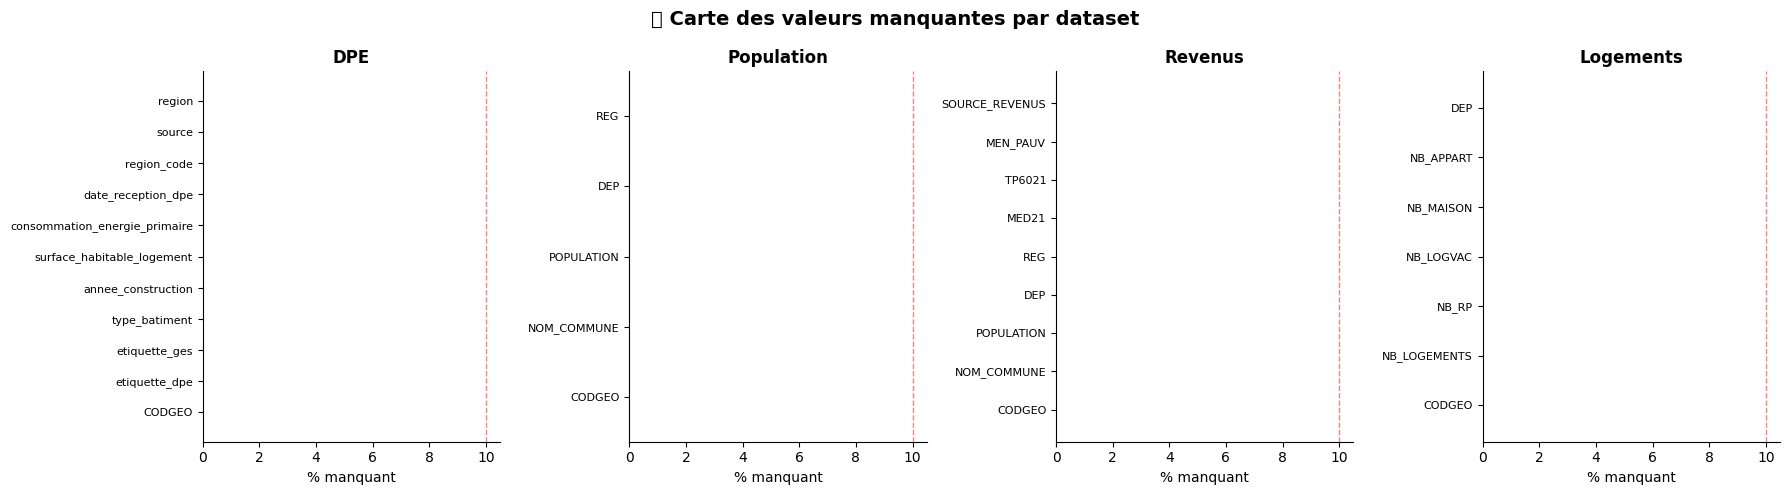

✅ Graphique sauvegardé


In [58]:
# ── Heatmap valeurs manquantes ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('🔍 Carte des valeurs manquantes par dataset', fontsize=14, fontweight='bold')

for ax, (nom, df) in zip(axes, datasets.items()):
    missing_pct = df.isnull().mean() * 100
    colors = ['#E74C3C' if v > 10 else '#F39C12' if v > 0 else '#27AE60' for v in missing_pct]
    bars = ax.barh(range(len(missing_pct)), missing_pct, color=colors)
    ax.set_yticks(range(len(missing_pct)))
    ax.set_yticklabels(missing_pct.index, fontsize=8)
    ax.set_xlabel('% manquant')
    ax.set_title(nom, fontweight='bold')
    ax.axvline(x=10, color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_valeurs_manquantes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

---
## 4️⃣ Distributions & Histogrammes

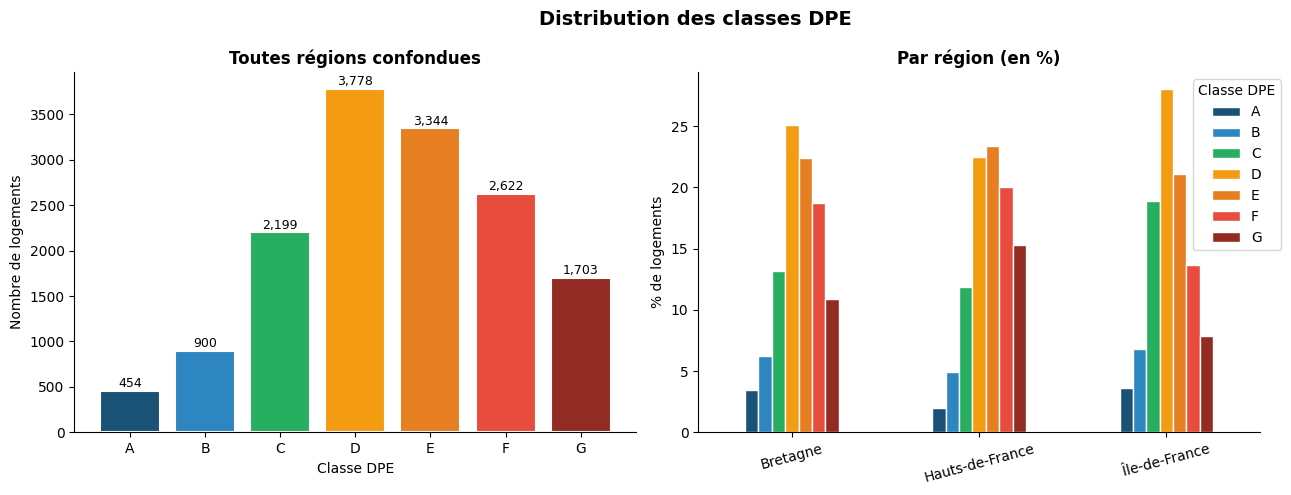

In [59]:
# ── Distribution des classes DPE ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des classes DPE', fontsize=14, fontweight='bold')

dpe_colors = {'A':'#1A5276','B':'#2E86C1','C':'#27AE60','D':'#F39C12','E':'#E67E22','F':'#E74C3C','G':'#922B21'}

# Global
counts = dpe['etiquette_dpe'].value_counts().sort_index()
bars = axes[0].bar(counts.index, counts.values,
                   color=[dpe_colors.get(c, '#95A5A6') for c in counts.index],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Toutes régions confondues', fontweight='bold')
axes[0].set_xlabel('Classe DPE')
axes[0].set_ylabel('Nombre de logements')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Par région
dpe_region = dpe.groupby(['region', 'etiquette_dpe']).size().unstack(fill_value=0)
dpe_region_pct = dpe_region.div(dpe_region.sum(axis=1), axis=0) * 100
dpe_region_pct.plot(kind='bar', ax=axes[1],
                    color=[dpe_colors.get(c, '#95A5A6') for c in dpe_region_pct.columns],
                    edgecolor='white', linewidth=1)
axes[1].set_title('Par région (en %)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% de logements')
axes[1].legend(title='Classe DPE', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_distribution_dpe.png', dpi=150, bbox_inches='tight')
plt.show()

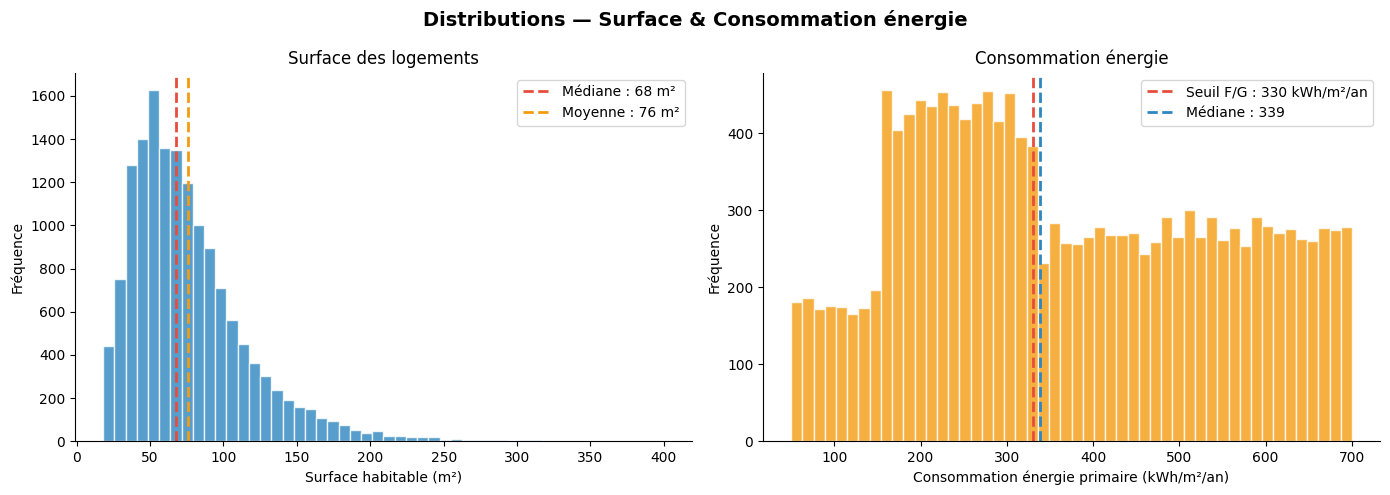

In [60]:
# ── Distribution surface & consommation ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distributions — Surface & Consommation énergie', fontsize=14, fontweight='bold')

# Surface
if 'surface_habitable_logement' in dpe.columns: 
    surf = pd.to_numeric(dpe['surface_habitable_logement'], errors='coerce').dropna()
    surf = surf[(surf > 5) & (surf < 500)]
    axes[0].hist(surf, bins=50, color=COLORS['blue'], alpha=0.8, edgecolor='white')
    axes[0].axvline(surf.median(), color=COLORS['red'], linestyle='--', linewidth=2,
                    label=f'Médiane : {surf.median():.0f} m²')
    axes[0].axvline(surf.mean(), color=COLORS['orange'], linestyle='--', linewidth=2,
                    label=f'Moyenne : {surf.mean():.0f} m²')
    axes[0].set_xlabel('Surface habitable (m²)')
    axes[0].set_ylabel('Fréquence')
    axes[0].set_title('Surface des logements')
    axes[0].legend()

# Consommation énergie
if 'consommation_energie_primaire' in dpe.columns:
    conso = pd.to_numeric(dpe['consommation_energie_primaire'], errors='coerce').dropna()
    conso = conso[(conso > 0) & (conso < 1500)]
    axes[1].hist(conso, bins=50, color=COLORS['orange'], alpha=0.8, edgecolor='white')
    axes[1].axvline(330, color=COLORS['red'], linestyle='--', linewidth=2,
                    label='Seuil F/G : 330 kWh/m²/an')
    axes[1].axvline(conso.median(), color=COLORS['blue'], linestyle='--', linewidth=2,
                    label=f'Médiane : {conso.median():.0f}')
    axes[1].set_xlabel('Consommation énergie primaire (kWh/m²/an)')
    axes[1].set_ylabel('Fréquence')
    axes[1].set_title('Consommation énergie')
    axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_distributions_surface_conso.png', dpi=150, bbox_inches='tight')
plt.show()

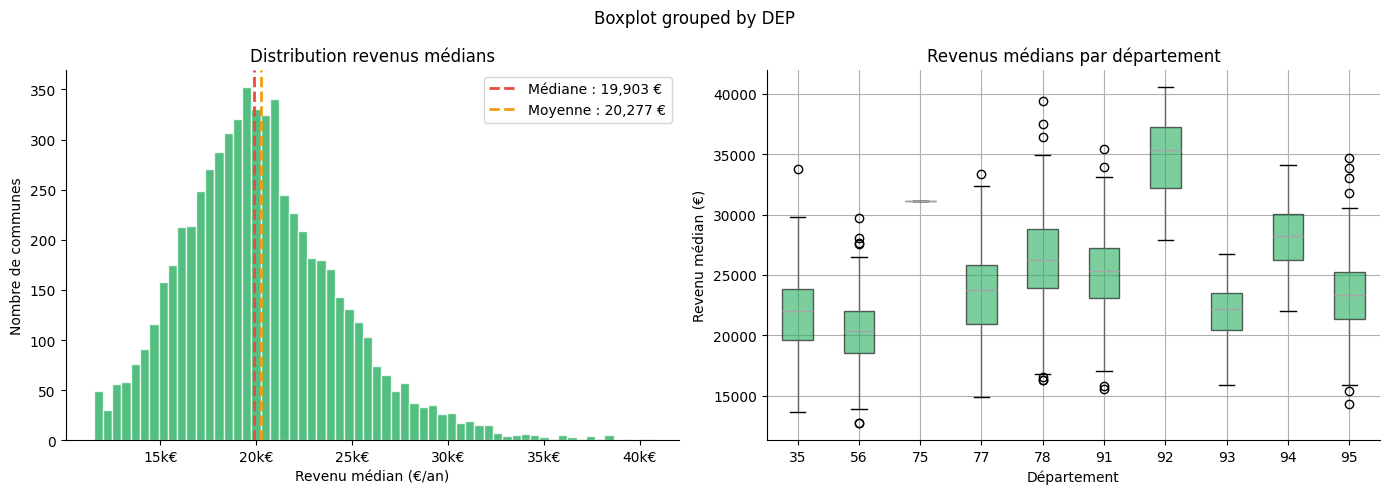

In [61]:
# ── Distribution revenus médians ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des Revenus Médians par commune', fontsize=14, fontweight='bold')

col_med = next((c for c in rev.columns if c.startswith('MED')), None)

if col_med:
    med = pd.to_numeric(rev[col_med], errors='coerce').dropna()
    
    # Histogramme
    axes[0].hist(med, bins=60, color=COLORS['green'], alpha=0.8, edgecolor='white')
    axes[0].axvline(med.median(), color=COLORS['red'], linestyle='--', linewidth=2,
                    label=f'Médiane : {med.median():,.0f} €')
    axes[0].axvline(med.mean(), color=COLORS['orange'], linestyle='--', linewidth=2,
                    label=f'Moyenne : {med.mean():,.0f} €')
    axes[0].set_xlabel('Revenu médian (€/an)')
    axes[0].set_ylabel('Nombre de communes')
    axes[0].set_title('Distribution revenus médians')
    axes[0].legend()
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k€'))

    # Boxplot par département
    if 'DEP' in rev.columns:
        rev_plot = rev[['DEP', col_med]].copy()
        rev_plot[col_med] = pd.to_numeric(rev_plot[col_med], errors='coerce')
        top_deps = rev_plot.groupby('DEP')[col_med].median().nlargest(10).index
        rev_plot[rev_plot['DEP'].isin(top_deps)].boxplot(
            column=col_med, by='DEP', ax=axes[1],
            patch_artist=True,
            boxprops=dict(facecolor=COLORS['green'], alpha=0.6)
        )
        axes[1].set_title('Top 10 départements')
        axes[1].set_xlabel('Département')
        axes[1].set_ylabel('Revenu médian (€)')
        plt.sca(axes[1])
        plt.title('Revenus médians par département')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_distribution_revenus.png', dpi=150, bbox_inches='tight')
plt.show()

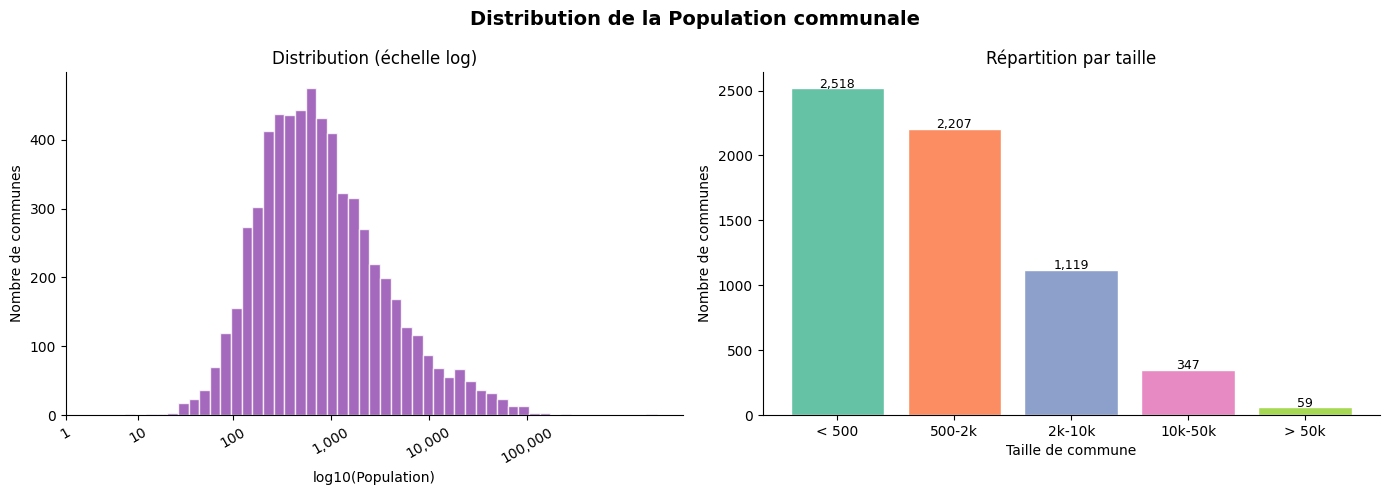

In [62]:
# ── Distribution population ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution de la Population communale', fontsize=14, fontweight='bold')

col_pop = next((c for c in pop.columns if 'POP' in c.upper() or c == 'POPULATION'), None)
if col_pop:
    pop_vals = pd.to_numeric(pop[col_pop], errors='coerce').dropna()
    pop_vals = pop_vals[pop_vals > 0]

    # Échelle log
    axes[0].hist(np.log10(pop_vals + 1), bins=50, color=COLORS['purple'], alpha=0.8, edgecolor='white')
    axes[0].set_xlabel('log10(Population)')
    axes[0].set_ylabel('Nombre de communes')
    axes[0].set_title('Distribution (échelle log)')
    ticks = [1, 10, 100, 1000, 10000, 100000]
    axes[0].set_xticks([np.log10(t+1) for t in ticks])
    axes[0].set_xticklabels([f'{t:,}' for t in ticks], rotation=30)

    # Catégories
    bins_pop = [0, 500, 2000, 10000, 50000, float('inf')]
    labels_pop = ['< 500', '500-2k', '2k-10k', '10k-50k', '> 50k']
    cat = pd.cut(pop_vals, bins=bins_pop, labels=labels_pop)
    cat_counts = cat.value_counts().sort_index()
    axes[1].bar(cat_counts.index, cat_counts.values,
                color=sns.color_palette('Set2', len(cat_counts)),
                edgecolor='white')
    for i, (idx, val) in enumerate(cat_counts.items()):
        axes[1].text(i, val + 5, f'{val:,}', ha='center', fontsize=9)
    axes[1].set_xlabel('Taille de commune')
    axes[1].set_ylabel('Nombre de communes')
    axes[1].set_title('Répartition par taille')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_distribution_population.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5️⃣ Analyse DPE — Focus Passoires Thermiques

 TAUX DE PASSOIRES THERMIQUES PAR RÉGION


,total,passoires,taux_pct
region,,,
Bretagne,5000,1483,29.66
Hauts-de-France,5000,1765,35.30
Île-de-France,5000,1077,21.54


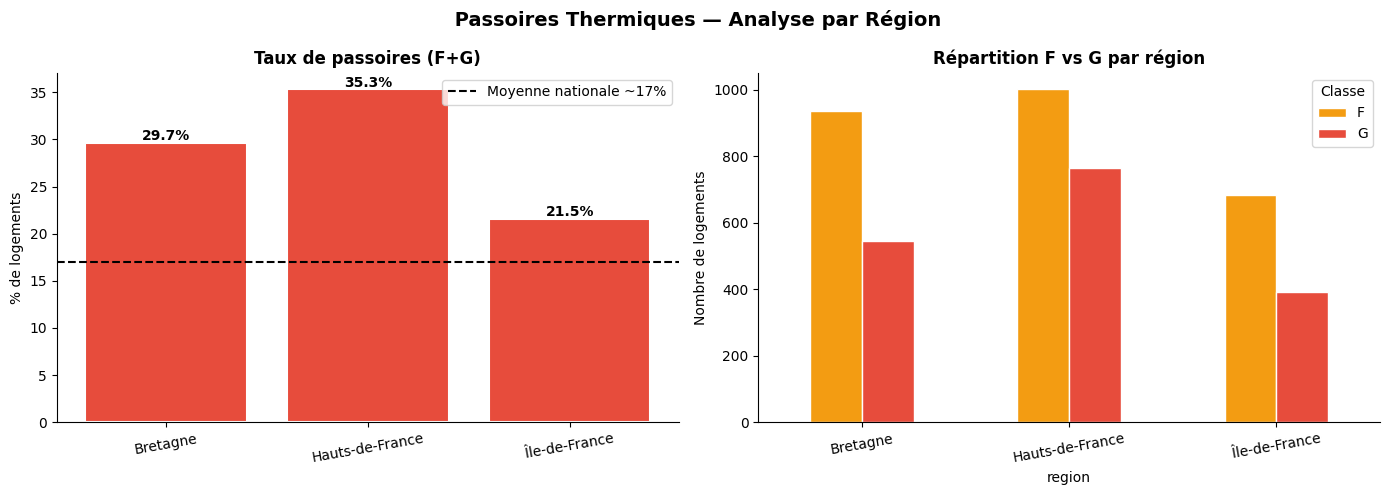

In [63]:
# ── Taux de passoires par région ──────────────────────
dpe['est_passoire'] = dpe['etiquette_dpe'].isin(['F', 'G'])

taux_region = dpe.groupby('region').agg(
    total=('etiquette_dpe', 'count'),
    passoires=('est_passoire', 'sum')
).assign(taux_pct=lambda x: x['passoires'] / x['total'] * 100).round(2)

print(' TAUX DE PASSOIRES THERMIQUES PAR RÉGION')
print('='*50)
display(taux_region)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' Passoires Thermiques — Analyse par Région', fontsize=14, fontweight='bold')

# Taux passoires
colors_bar = [COLORS['red'] if v > 20 else COLORS['orange'] if v > 15 else COLORS['green']
              for v in taux_region['taux_pct']]
bars = axes[0].bar(taux_region.index, taux_region['taux_pct'],
                   color=colors_bar, edgecolor='white', linewidth=1.5)
axes[0].axhline(y=17, color='black', linestyle='--', linewidth=1.5,
                label='Moyenne nationale ~17%')
for bar, val in zip(bars, taux_region['taux_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Taux de passoires (F+G)', fontweight='bold')
axes[0].set_ylabel('% de logements')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=10)

# Répartition F vs G
fg = dpe[dpe['est_passoire']].groupby(['region', 'etiquette_dpe']).size().unstack(fill_value=0)
fg.plot(kind='bar', ax=axes[1],
        color=[COLORS['orange'], COLORS['red']],
        edgecolor='white', linewidth=1)
axes[1].set_title('Répartition F vs G par région', fontweight='bold')
axes[1].set_ylabel('Nombre de logements')
axes[1].legend(title='Classe')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_passoires_par_region.png', dpi=150, bbox_inches='tight')
plt.show()

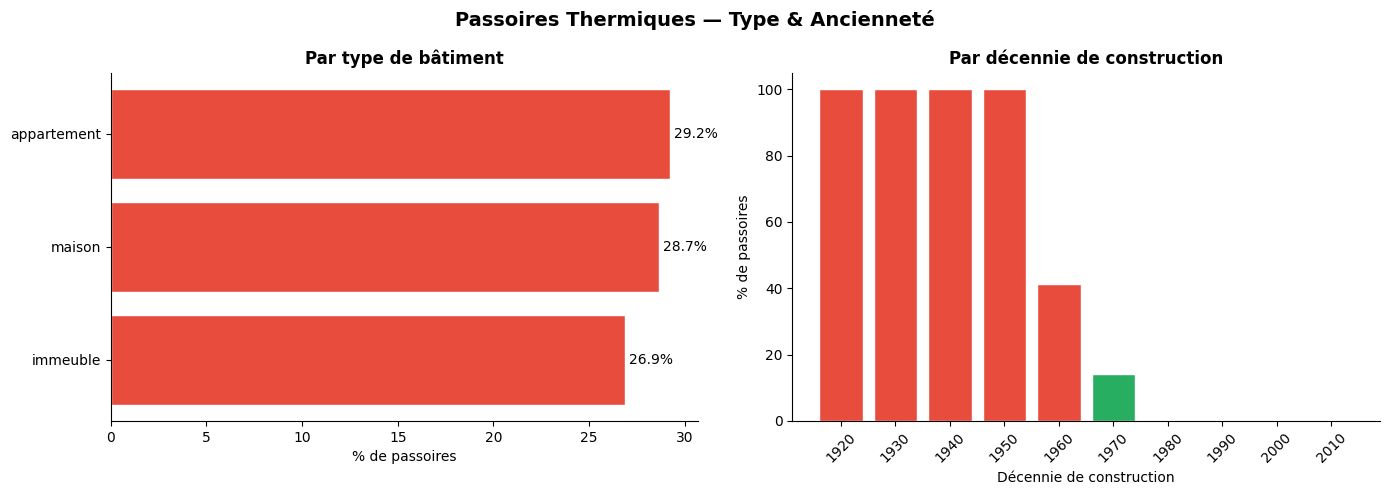


💡 OBSERVATION : Les logements construits avant 1975 (avant la 1ère réglementation thermique)
   ont un taux de passoires significativement plus élevé.


In [64]:
# ── Passoires par type de bâtiment & année ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Passoires Thermiques — Type & Ancienneté', fontsize=14, fontweight='bold')

# Par type bâtiment
if 'type_batiment' in dpe.columns:
    type_taux = dpe.groupby('type_batiment')['est_passoire'].agg(['sum','count'])
    type_taux['taux'] = type_taux['sum'] / type_taux['count'] * 100
    type_taux = type_taux.sort_values('taux', ascending=True)
    axes[0].barh(type_taux.index, type_taux['taux'],
                 color=[COLORS['red'] if v > 20 else COLORS['orange'] for v in type_taux['taux']],
                 edgecolor='white')
    for i, val in enumerate(type_taux['taux']):
        axes[0].text(val + 0.2, i, f'{val:.1f}%', va='center')
    axes[0].set_xlabel('% de passoires')
    axes[0].set_title('Par type de bâtiment', fontweight='bold')

# Par décennie de construction
if 'annee_construction' in dpe.columns:
    dpe['decennie'] = (pd.to_numeric(dpe['annee_construction'], errors='coerce') // 10 * 10).astype('Int64')
    dec_taux = dpe.groupby('decennie')['est_passoire'].agg(['sum','count'])
    dec_taux['taux'] = dec_taux['sum'] / dec_taux['count'] * 100
    dec_taux = dec_taux.dropna().sort_index()
    dec_taux = dec_taux[(dec_taux.index >= 1900) & (dec_taux.index <= 2020)]
    axes[1].bar(dec_taux.index.astype(str), dec_taux['taux'],
                color=[COLORS['red'] if v > 25 else COLORS['orange'] if v > 15 else COLORS['green']
                       for v in dec_taux['taux']],
                edgecolor='white')
    axes[1].set_xlabel('Décennie de construction')
    axes[1].set_ylabel('% de passoires')
    axes[1].set_title('Par décennie de construction', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_passoires_type_annee.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 OBSERVATION : Les logements construits avant 1975 (avant la 1ère réglementation thermique)')
print('   ont un taux de passoires significativement plus élevé.')

In [65]:
# ── Top 20 communes avec le plus de passoires ─────────
passoires_par_commune = dpe.groupby('CODGEO').agg(
    total_dpe=('etiquette_dpe', 'count'),
    nb_passoires=('est_passoire', 'sum'),
    region=('region', 'first')
).assign(
    taux_passoires=lambda x: (x['nb_passoires'] / x['total_dpe'] * 100).round(2)
).sort_values('nb_passoires', ascending=False)

print(' TOP 20 COMMUNES — Plus de passoires thermiques (volume)')
display(passoires_par_commune.head(20))

print('\n TOP 20 COMMUNES — Plus fort taux de passoires (% minimum 10 DPE)')
display(passoires_par_commune[passoires_par_commune['total_dpe'] >= 10]
        .sort_values('taux_passoires', ascending=False).head(20))

 TOP 20 COMMUNES — Plus de passoires thermiques (volume)


,total_dpe,nb_passoires,region,taux_passoires
CODGEO,,,,
59374,8,6,Hauts-de-France,75.00
62265,7,5,Hauts-de-France,71.43
62269,5,5,Hauts-de-France,100.00
60398,6,5,Hauts-de-France,83.33
59146,7,5,Hauts-de-France,71.43
29259,10,5,Bretagne,50.00
22159,7,5,Bretagne,71.43
35217,8,5,Bretagne,62.50
02225,5,4,Hauts-de-France,80.00



 TOP 20 COMMUNES — Plus fort taux de passoires (% minimum 10 DPE)


,total_dpe,nb_passoires,region,taux_passoires
CODGEO,,,,
29259,10,5,Bretagne,50.00
56019,10,4,Bretagne,40.00
35215,10,3,Bretagne,30.00
29321,13,2,Bretagne,15.38


---
## 6️⃣ Analyse Population & Revenus

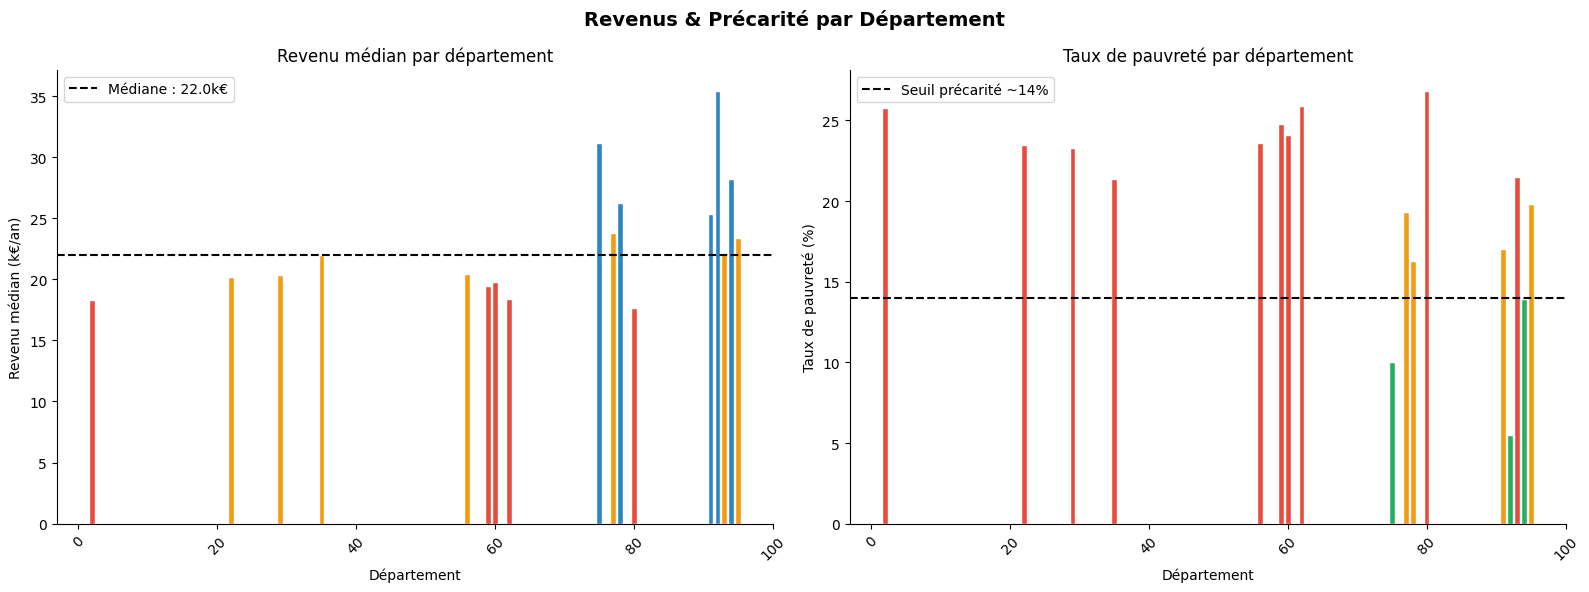

In [66]:
# ── Revenus médians par département ───────────────────
col_med = next((c for c in rev.columns if c.startswith('MED')), None)
col_tp  = next((c for c in rev.columns if c.startswith('TP')), None)

if col_med and 'DEP' in rev.columns:
    rev[col_med] = pd.to_numeric(rev[col_med], errors='coerce')
    rev_dep = rev.groupby('DEP')[col_med].median().sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Revenus & Précarité par Département', fontsize=14, fontweight='bold')

    colors_rev = [COLORS['blue'] if v > 25000 else COLORS['orange'] if v > 20000 else COLORS['red']
                  for v in rev_dep.values]
    axes[0].bar(rev_dep.index, rev_dep.values / 1000, color=colors_rev, edgecolor='white')
    axes[0].axhline(y=rev_dep.median() / 1000, color='black', linestyle='--', linewidth=1.5,
                    label=f'Médiane : {rev_dep.median()/1000:.1f}k€')
    axes[0].set_xlabel('Département')
    axes[0].set_ylabel('Revenu médian (k€/an)')
    axes[0].set_title('Revenu médian par département')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)

    if col_tp:
        rev[col_tp] = pd.to_numeric(rev[col_tp], errors='coerce')
        tp_dep = rev.groupby('DEP')[col_tp].median().sort_values(ascending=False)
        colors_tp = [COLORS['red'] if v > 20 else COLORS['orange'] if v > 15 else COLORS['green']
                     for v in tp_dep.values]
        axes[1].bar(tp_dep.index, tp_dep.values, color=colors_tp, edgecolor='white')
        axes[1].axhline(y=14, color='black', linestyle='--', linewidth=1.5,
                        label='Seuil précarité ~14%')
        axes[1].set_xlabel('Département')
        axes[1].set_ylabel('Taux de pauvreté (%)')
        axes[1].set_title('Taux de pauvreté par département')
        axes[1].legend()
        axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/08_revenus_pauvrete.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 7️⃣ Corrélations entre Variables

In [67]:
# ── Préparation dataset fusionné pour corrélations ────
# Agréger DPE par commune
dpe_comm = dpe.groupby('CODGEO').agg(
    nb_dpe=('etiquette_dpe', 'count'),
    nb_passoires=('est_passoire', 'sum'),
    taux_passoires=('est_passoire', 'mean'),
    conso_moy=('consommation_energie_primaire', lambda x: pd.to_numeric(x, errors='coerce').mean()),
    surf_moy=('surface_habitable_logement', lambda x: pd.to_numeric(x, errors='coerce').mean()),
).reset_index()
dpe_comm['taux_passoires'] *= 100

# Colonnes revenus
rev_cols = ['CODGEO']
for c in [col_med, col_tp, 'MEN_PAUV', 'POPULATION']:
    if c and c in rev.columns:
        rev_cols.append(c)
        rev[c] = pd.to_numeric(rev[c], errors='coerce')

# Population
col_pop = next((c for c in pop.columns if 'POP' in c.upper() or c == 'POPULATION'), None)
pop_sel = pop[['CODGEO', col_pop]].copy() if col_pop else pop[['CODGEO']].copy()
if col_pop:
    pop_sel[col_pop] = pd.to_numeric(pop_sel[col_pop], errors='coerce')
    pop_sel = pop_sel.rename(columns={col_pop: 'POPULATION'})

# Fusion
df_corr = dpe_comm.merge(rev[rev_cols], on='CODGEO', how='left')
if 'POPULATION' not in df_corr.columns:
    df_corr = df_corr.merge(pop_sel, on='CODGEO', how='left')

# Colonnes numériques uniquement
df_num = df_corr.select_dtypes(include='number').dropna(axis=1, thresh=int(len(df_corr)*0.5))

print(f' Dataset corrélations : {df_num.shape[0]} communes × {df_num.shape[1]} variables')
display(df_num.head(3))

 Dataset corrélations : 5738 communes × 9 variables


,nb_dpe,nb_passoires,taux_passoires,conso_moy,surf_moy,MED21,TP6021,MEN_PAUV,POPULATION
0,1,0,0.0,198.00,153.60,16978.0,27.4,27.9,518.0
1,4,0,0.0,358.50,68.75,12413.0,30.1,28.1,584.0
2,4,2,50.0,386.25,69.55,19710.0,21.6,19.9,1004.0


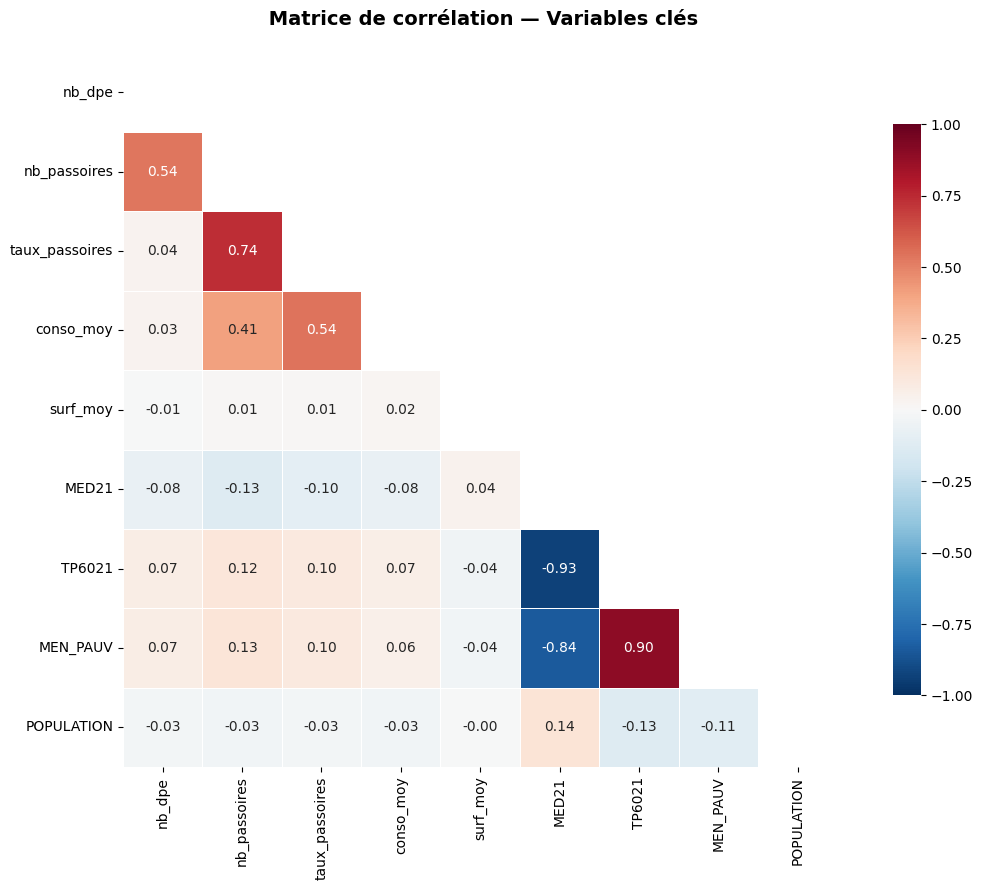


 Corrélations avec le taux de passoires :


,Corrélation
MED21,-0.099514
POPULATION,-0.026912
surf_moy,0.013211
nb_dpe,0.036839
TP6021,0.096533
MEN_PAUV,0.096534
conso_moy,0.543302
nb_passoires,0.735288


In [68]:
# ── Matrice de corrélation ────────────────────────────
if df_num.shape[1] >= 3:
    corr_matrix = df_num.corr()

    fig, ax = plt.subplots(figsize=(12, 9))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5,
        cbar_kws={'shrink': 0.8},
        ax=ax
    )
    ax.set_title(' Matrice de corrélation — Variables clés', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/09_matrice_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Corrélations avec taux_passoires
    if 'taux_passoires' in corr_matrix.columns:
        corr_passoires = corr_matrix['taux_passoires'].drop('taux_passoires').sort_values()
        print('\n Corrélations avec le taux de passoires :')
        display(corr_passoires.to_frame('Corrélation').style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1))

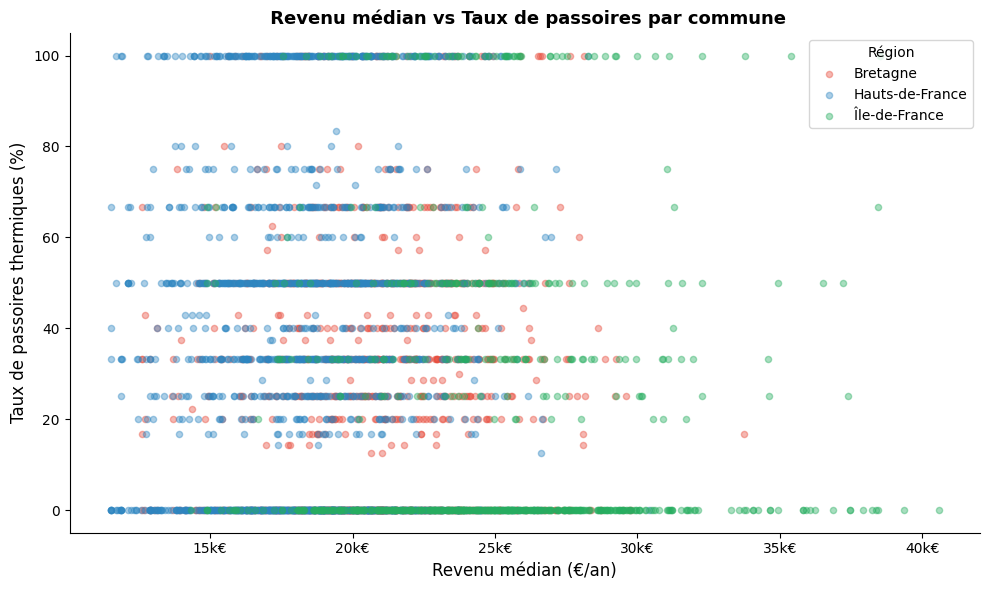


 OBSERVATION : Une corrélation négative entre revenu médian et taux de passoires
   confirme que les communes les plus pauvres ont plus de passoires thermiques.


In [69]:
# ── Scatter : Revenu médian vs Taux passoires ─────────
if col_med and 'taux_passoires' in df_corr.columns and col_med in df_corr.columns:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Couleur par région
    if 'region' in dpe.set_index('CODGEO').columns:
        df_plot = df_corr.merge(dpe[['CODGEO','region']].drop_duplicates(), on='CODGEO', how='left')
    else:
        df_plot = df_corr.copy()
        df_plot['region'] = 'Non défini'

    regions_uniq = df_plot['region'].unique()
    palette = {r: c for r, c in zip(regions_uniq, [COLORS['blue'], COLORS['red'], COLORS['green']])}

    for region, grp in df_plot.groupby('region'):
        x = pd.to_numeric(grp[col_med], errors='coerce')
        y = pd.to_numeric(grp['taux_passoires'], errors='coerce')
        mask = x.notna() & y.notna()
        ax.scatter(x[mask], y[mask], alpha=0.4, s=20,
                   color=palette.get(region, COLORS['gray']),
                   label=region)

    ax.set_xlabel('Revenu médian (€/an)', fontsize=12)
    ax.set_ylabel('Taux de passoires thermiques (%)', fontsize=12)
    ax.set_title(' Revenu médian vs Taux de passoires par commune',
                 fontsize=13, fontweight='bold')
    ax.legend(title='Région')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k€'))

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/10_scatter_revenu_passoires.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n OBSERVATION : Une corrélation négative entre revenu médian et taux de passoires')
    print('   confirme que les communes les plus pauvres ont plus de passoires thermiques.')

---
## 8️⃣ Visualisation Géographique

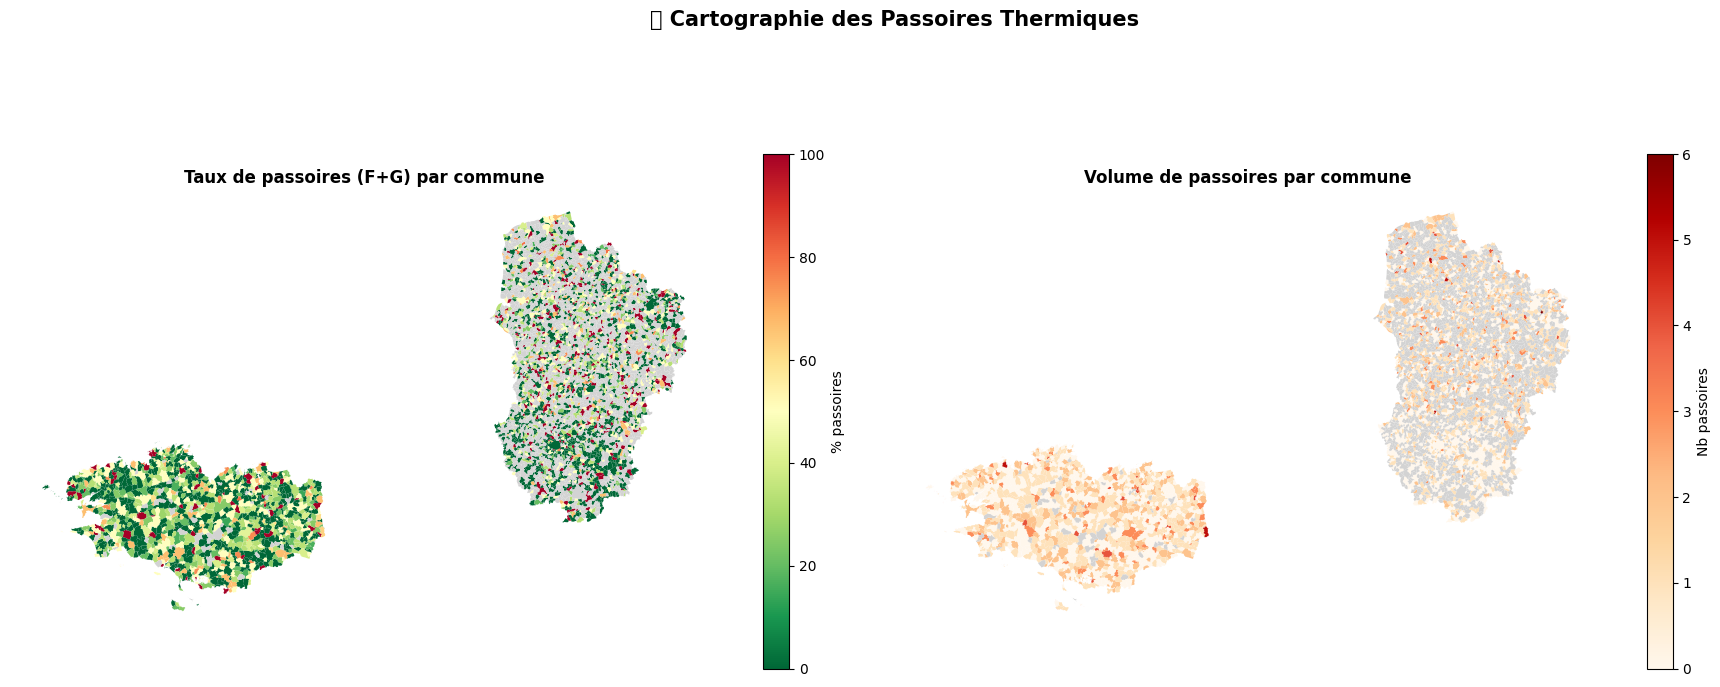

 Carte sauvegardée


In [70]:
# ── Carte choroplèthe — Taux de passoires ─────────────
# Joindre taux passoires au GeoJSON
col_geo = next((c for c in geo.columns if c in ['code', 'insee_com', 'CODGEO', 'CODE']), None)
if col_geo:
    geo_plot = geo.rename(columns={col_geo: 'CODGEO'}).copy()
else:
    geo_plot = geo.copy()
    geo_plot['CODGEO'] = geo_plot.iloc[:, 0].astype(str)

geo_plot['CODGEO'] = geo_plot['CODGEO'].astype(str).str.zfill(5)
dpe_comm['CODGEO']  = dpe_comm['CODGEO'].astype(str).str.zfill(5)

geo_dpe = geo_plot.merge(dpe_comm[['CODGEO', 'taux_passoires', 'nb_passoires']], on='CODGEO', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('🗺️ Cartographie des Passoires Thermiques', fontsize=15, fontweight='bold')

# Carte taux
geo_dpe.plot(
    column='taux_passoires',
    ax=axes[0], cmap='RdYlGn_r',
    legend=True,
    missing_kwds={'color': 'lightgray', 'label': 'Sans données'},
    legend_kwds={'label': '% passoires', 'shrink': 0.7}
)
axes[0].set_title('Taux de passoires (F+G) par commune', fontweight='bold')
axes[0].axis('off')

# Carte volume
geo_dpe.plot(
    column='nb_passoires',
    ax=axes[1], cmap='OrRd',
    legend=True,
    missing_kwds={'color': 'lightgray', 'label': 'Sans données'},
    legend_kwds={'label': 'Nb passoires', 'shrink': 0.7}
)
axes[1].set_title('Volume de passoires par commune', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_carte_passoires.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Carte sauvegardée')

---
## 9️⃣ Synthèse & Problèmes Qualité Détectés

In [71]:
print('=' * 65)
print(' SYNTHÈSE EDA — PROJET PASSOIRES THERMIQUES')
print('=' * 65)

print('\n VOLUME DES DONNÉES :')
print(f'   DPE total collectés    : {len(dpe):,} logements')
print(f'   dont passoires F/G     : {dpe["est_passoire"].sum():,} ({dpe["est_passoire"].mean()*100:.1f}%)')
print(f'   Communes DPE couvertes : {dpe["CODGEO"].nunique():,}')
print(f'   Communes population    : {len(pop):,}')
print(f'   Communes revenus       : {len(rev):,}')

print('\n PROBLÈMES QUALITÉ DÉTECTÉS (→ à corriger étape nettoyage) :')

# Vérifier codes INSEE
dpe_codes = set(dpe['CODGEO'].dropna().unique())
pop_codes  = set(pop['CODGEO'].dropna().unique())
rev_codes  = set(rev['CODGEO'].dropna().unique())
log_codes  = set(log['CODGEO'].dropna().unique())

print(f'   Codes INSEE DPE non matchés population : {len(dpe_codes - pop_codes):,}')
print(f'   Codes INSEE DPE non matchés revenus    : {len(dpe_codes - rev_codes):,}')
print(f'   Codes INSEE DPE non matchés logements  : {len(dpe_codes - log_codes):,}')

# Valeurs aberrantes
if 'surface_habitable_logement' in dpe.columns:
    surf = pd.to_numeric(dpe['surface_habitable_logement'], errors='coerce')
    aberrants_surf = ((surf < 5) | (surf > 500)).sum()
    print(f'   Surface aberrante (<5 ou >500 m²)      : {aberrants_surf:,}')

if 'annee_construction' in dpe.columns:
    annee = pd.to_numeric(dpe['annee_construction'], errors='coerce')
    aberrants_annee = ((annee < 1800) | (annee > 2025)).sum()
    print(f'   Année construction aberrante           : {aberrants_annee:,}')



 SYNTHÈSE EDA — PROJET PASSOIRES THERMIQUES

 VOLUME DES DONNÉES :
   DPE total collectés    : 15,000 logements
   dont passoires F/G     : 4,325 (28.8%)
   Communes DPE couvertes : 5,738
   Communes population    : 6,250
   Communes revenus       : 6,250

 PROBLÈMES QUALITÉ DÉTECTÉS (→ à corriger étape nettoyage) :
   Codes INSEE DPE non matchés population : 2,126
   Codes INSEE DPE non matchés revenus    : 2,126
   Codes INSEE DPE non matchés logements  : 4,266
   Surface aberrante (<5 ou >500 m²)      : 0
   Année construction aberrante           : 0


In [72]:
# ── Récap graphique final ─────────────────────────────
print(f'\n Graphiques EDA sauvegardés dans : {OUTPUT_DIR}/')
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith('.png'):
        print(f'    {f}')


 Graphiques EDA sauvegardés dans : outputs/eda/
    01_valeurs_manquantes.png
    02_distribution_dpe.png
    03_distributions_surface_conso.png
    04_distribution_revenus.png
    05_distribution_population.png
    06_passoires_par_region.png
    07_passoires_type_annee.png
    08_revenus_pauvrete.png
    09_matrice_correlation.png
    10_scatter_revenu_passoires.png
    11_carte_passoires.png
